# Rainbow ATM book — the regression delta: three deltas as three β surfaces

**Question (user, 2026-10-05).** The sticky-strike bump delta leaves the
delta-hedged ATM book with an SPX beta and a vol line that trends with the
rally. Would a bump delta that *co-moves the vol surface by its correlation
with the equity* hedge better? Bump the equity, and when you do, shift every
point of the implied-vol surface by its in-sample regression slope on that
equity's return — the Hull–White minimum-variance ("shadow") delta, built
formula-free.

**Construct.** Every delta in this notebook is the *same* central bump:
index *j*'s spot to S_j(1 ± 1%), its seasoning scaled, and its implied
marginal rebuilt from the pillar grid shifted by **β_j · (±1%)** through the
factory's additive `dgrid` seam. The frameworks differ only in β, the
assumed fixed-moneyness response of the surface to a unit spot move:

| label | β(τ, m) | what it is |
|---|---|---|
| `sm` | 0 | tables frozen, the smile rides with spot — sticky moneyness (the autograd delta's construct) |
| `ss` | m·∂σ/∂m, the local smile slope (`sticky_strike_beta`) | the strike relabeling σ_new(m) = σ_old(m(1+ε)) — the current `rainbow_attribution_ss` / `book_greeks` delta, identical construct and CRN points, matches that cache to fp |
| `h1` | in-sample OLS slope of each pillar's daily fixed-moneyness change on the index's own daily return (`spot_vol_betas`) | **the regression delta** |
| `h5`, `h20`, `h60` | the same from 5/20/60-step overlapping changes and returns | the horizon ladder |
| `big` | daily slope on \|ret\| ≥ 1% days only | the big-move variant |

Betas are per index, per pillar, estimated on the joint-date axis (the
attribution's day pairs) over the whole sample — in sample on purpose. The
same seam re-cuts the P&L for `sm`, `ss` and `h1`: `eq_<L>` = all spots → t
with each grid shifted by β_j·ret_j (the response the delta assumes),
`vol_<L>` = the day-t surfaces net of that shift (the regression residual of
the surface), `cross_<L>` = the rest; eq + vol + cross is the same number
for every label.

Driver `rainbow_regression_delta` (`vol_pca/rainbow_torch.py`), cache script
`scripts/run_rainbow_regdelta.py` → `data/rainbow_regdelta.csv` +
`data/rainbow_regdelta_betas.npz`. Comparison set: the two ATM attribution
caches (`rainbow_attribution_ss_atm.csv`, `rainbow_attribution_sm_atm.csv`,
same 512 paths / seed). Desk convention as in `rainbow_attribution_atm.ipynb`:
the desk keeps `pl − eq_delta − theta_value − theta_delta`, with the two
carry lines taken from the sticky-strike cache for every delta (the
`theta_delta` line is built from the SS deltas; the inconsistency is
−\$0.06M scale).

In [1]:
import time
T0 = time.time()
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from vol_pca.surface import MONEYNESS, TTM_PILLARS

rd = pd.read_csv("data/rainbow_regdelta.csv", parse_dates=["date"], index_col="date")
ss = pd.read_csv("data/rainbow_attribution_ss_atm.csv", parse_dates=["date"], index_col="date")
sm = pd.read_csv("data/rainbow_attribution_sm_atm.csv", parse_dates=["date"], index_col="date")
bz = np.load("data/rainbow_regdelta_betas.npz")
IDX = ["spx", "sx5e", "hsi"]
NAMES = {"spx": "SPX", "sx5e": "SX5E", "hsi": "HSI"}
LABELS = ["sm", "ss", "h1", "h5", "h20", "h60", "big"]
PRETTY = {"sm": "sticky moneyness (β=0)", "ss": "sticky strike (current)",
          "h1": "regression, daily β", "h5": "regression, 5d β",
          "h20": "regression, 20d β", "h60": "regression, 60d β",
          "big": "regression, |ret|≥1% β"}
assert (rd.index == ss.index).all() and (rd.index == sm.index).all()
chk = {"pl vs SS cache": (rd["pl"] - ss["pl"]).abs().max(),
       "pl vs SM cache": (rd["pl"] - sm["pl"]).abs().max(),
       "eq_delta_ss vs SS cache eq_delta": (rd["eq_delta_ss"] - ss["eq_delta"]).abs().max(),
       "recut ss (eq, vol, cross) vs SS cache": max((rd["eq_ss"] - ss["eq"]).abs().max(),
                                                   (rd["vol_ss"] - ss["vol"]).abs().max(),
                                                   (rd["cross_ss"] - ss["cross_ev"]).abs().max()),
       "recut sm (eq, vol, cross) vs SM cache": max((rd["eq_sm"] - sm["eq"]).abs().max(),
                                                   (rd["vol_sm"] - sm["vol"]).abs().max(),
                                                   (rd["cross_sm"] - sm["cross_sv"]).abs().max()),
       "eq+vol+cross label-independent (ss vs h1)": (rd[["eq_ss", "vol_ss", "cross_ss"]].sum(axis=1)
                                                    - rd[["eq_h1", "vol_h1", "cross_h1"]].sum(axis=1)).abs().max()}
print(f"{len(rd)} date pairs, {rd.index[0].date()} -> {rd.index[-1].date()}")
print("identity checks, max |diff| in $:")
for k, v in chk.items():
    print(f"  {k:48s} {v:.2e}")

1968 date pairs, 2018-12-28 -> 2026-07-31
identity checks, max |diff| in $:
  pl vs SS cache                                   0.00e+00
  pl vs SM cache                                   0.00e+00
  eq_delta_ss vs SS cache eq_delta                 1.21e-06
  recut ss (eq, vol, cross) vs SS cache            0.00e+00
  recut sm (eq, vol, cross) vs SM cache            5.82e-11
  eq+vol+cross label-independent (ss vs h1)        1.86e-09


## The β surfaces

β is in vol points per 1% spot move at each pillar. The `ss` curve is the
sticky-strike relabeling's implied response, m·∂σ/∂m of the average smile;
the others are what the surfaces actually did, in sample.

β in vol pts per 1% move (negative = the surface falls when spot rises)
           1Y 90  1Y ATM  1Y 110  3M ATM  R² 1Y ATM  R² 3M ATM       n
index β                                                               
SPX   ss   -0.32   -0.37   -0.30   -0.65        NaN        NaN     NaN
      h1   -0.40   -0.42   -0.41   -0.85       0.72       0.69  1968.0
      h5   -0.39   -0.41   -0.39   -0.81       0.63       0.62  1964.0
      h20  -0.38   -0.41   -0.41   -0.82       0.70       0.70  1949.0
      h60  -0.34   -0.37   -0.38   -0.70       0.66       0.66  1909.0
      big  -0.41   -0.43   -0.43   -0.87       0.79       0.76   527.0
SX5E  ss   -0.30   -0.28   -0.20   -0.53        NaN        NaN     NaN
      h1   -0.40   -0.38   -0.35   -0.76       0.72       0.69  1968.0
      h5   -0.40   -0.39   -0.36   -0.77       0.71       0.73  1964.0
      h20  -0.37   -0.36   -0.33   -0.72       0.71       0.69  1949.0
      h60  -0.33   -0.32   -0.30   -0.60       0.70       0.69  1909.0
     

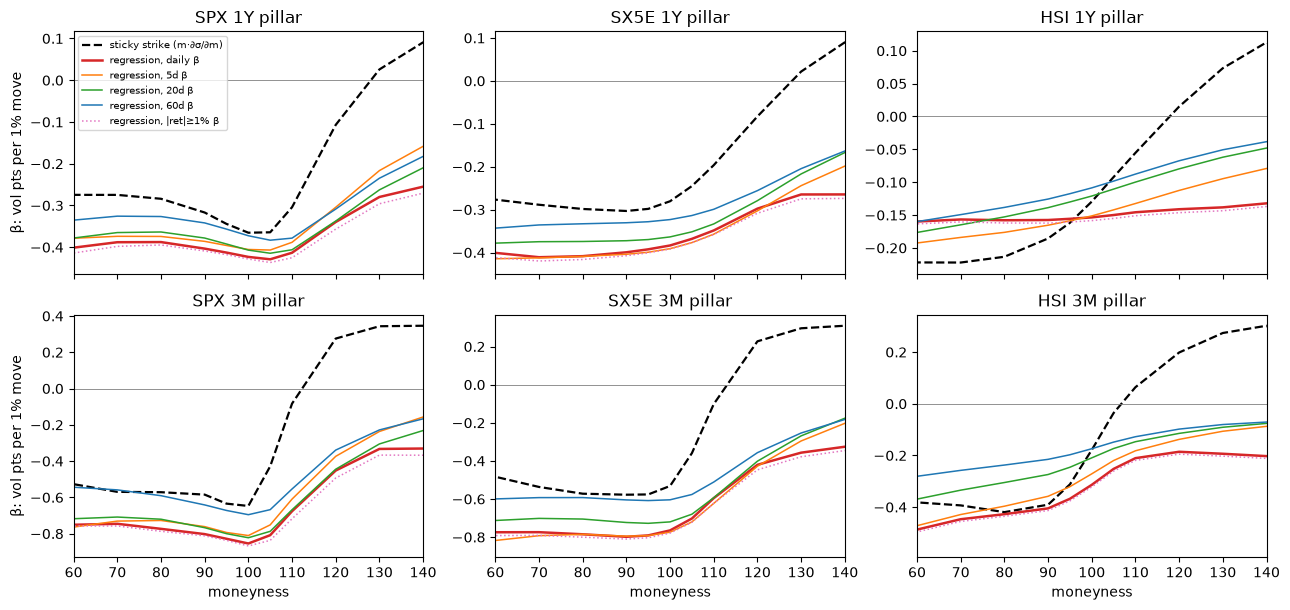

In [2]:
j1, j3 = len(TTM_PILLARS) - 1, 2            # 1Y and 3M pillars
fig, axes = plt.subplots(2, 3, figsize=(13, 6.2), sharex=True)
styles = {"ss": dict(color="k", ls="--", lw=1.6), "h1": dict(color="C3", lw=1.8),
          "h5": dict(color="C1", lw=1.1), "h20": dict(color="C2", lw=1.1),
          "h60": dict(color="C0", lw=1.1), "big": dict(color="C6", lw=1.1, ls=":")}
for col, n in enumerate(IDX):
    for row, (jp, lab) in enumerate([(j1, "1Y"), (j3, "3M")]):
        ax = axes[row, col]
        for L in ["ss", "h1", "h5", "h20", "h60", "big"]:
            ax.plot(MONEYNESS, bz[f"beta_{L}_{NAMES[n]}"][jp], label=PRETTY[L] if L != "ss" else "sticky strike (m·∂σ/∂m)", **styles[L])
        ax.axhline(0, color="grey", lw=0.6)
        ax.set(title=f"{NAMES[n]} {lab} pillar", xlim=(60, 140))
        if col == 0:
            ax.set_ylabel("β: vol pts per 1% move")
        if row == 1:
            ax.set_xlabel("moneyness")
axes[0, 0].legend(fontsize=7)
plt.tight_layout()

rows = []
for n in IDX:
    for L in ["ss", "h1", "h5", "h20", "h60", "big"]:
        b = bz[f"beta_{L}_{NAMES[n]}"]
        r = bz.get(f"r2_{L}_{NAMES[n]}")
        rows.append({"index": NAMES[n], "β": L, "1Y 90": b[j1, 4], "1Y ATM": b[j1, 6], "1Y 110": b[j1, 8],
                     "3M ATM": b[j3, 6], "R² 1Y ATM": np.nan if r is None else r[j1, 6],
                     "R² 3M ATM": np.nan if r is None else r[j3, 6],
                     "n": np.nan if r is None else int(bz[f"n_{L}_{NAMES[n]}"])})
bt = pd.DataFrame(rows).set_index(["index", "β"])
print("β in vol pts per 1% move (negative = the surface falls when spot rises)")
print(bt.round(2).to_string())

Three things the β surfaces say before any pricing:

- **The data's response is only slightly stronger than the sticky-strike
  relabeling at the money.** SPX 1Y ATM: the smile slope implies −0.37 vol
  pts per 1% move, the daily regression measures −0.42 (R² 0.72); SX5E −0.28
  vs −0.38; the 3M pillar roughly doubles both. So "sticky strike" is already
  ~90% of the empirical daily response at the strikes that carry the vega —
  the sticky-moneyness assumption (β = 0) is the outlier, not sticky strike.
- **The shapes differ.** The relabeling's β is the smile slope, so it fades
  through the call wing and turns *positive* where the smile rises (SPX 1Y:
  −0.30 at 110, −0.11 at 120, +0.1 at 140; 3M: positive from 115). The
  regression's β stays negative and almost flat in moneyness (−0.41 at 110,
  −0.34 at 120): when spot moves, the whole surface shifts in level; the
  smile slope is not what moves it.
  For HSI the two cross — the relabeling is *more* negative than the data on
  the put wing and less on the call wing — and the HSI regressions explain
  little (R² ~0.2).
- **Horizon barely matters for the slope.** The 5- and 20-day β are within
  a few hundredths of the daily one; at 60 days SPX ATM is back to −0.37 —
  the sticky-strike number. The big-move β (|ret| ≥ 1% days, ~27% of the
  sample) is −0.43: OLS already weights big days by their squared return,
  so re-tuning to them changes little.

## The deltas through time

Sold-book deltas in \$ per 1% move of each index. All three are the same
bump; only β differs, so the ordering follows β: the more negative the
assumed surface response, the less negative the sold call's delta (vol
falling on an up-move claws back part of the call's gain).

mean sold-book delta, $k per 1% move
         sm     ss     h1     h5    h20    h60    big
SPX  -861.4 -761.2 -735.8 -741.6 -739.7 -753.4 -733.5
SX5E -686.7 -620.1 -591.5 -590.7 -598.3 -609.3 -589.5
HSI  -357.0 -346.3 -343.6 -344.5 -347.1 -348.5 -343.2

where each regression delta sits on the SS(0) -> SM(1) segment, median over dates
        h1    h5   h20   h60   big
SPX  -0.24 -0.19 -0.20 -0.07 -0.26
SX5E -0.48 -0.50 -0.38 -0.21 -0.51
HSI  -0.20 -0.12  0.10  0.22 -0.23


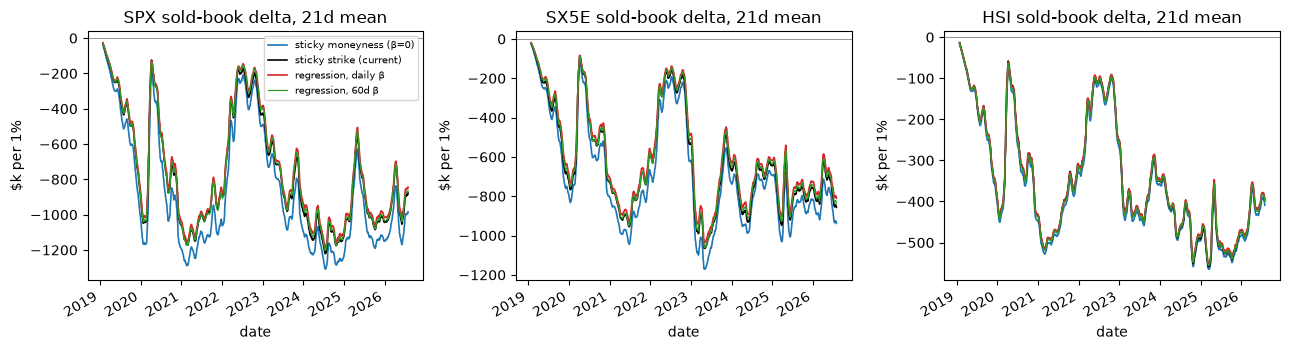

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, n in zip(axes, IDX):
    for L, st in [("sm", dict(color="C0")), ("ss", dict(color="k")), ("h1", dict(color="C3")), ("h60", dict(color="C2", lw=0.9))]:
        (rd[f"delta_{L}_{n}"] / 1e2 / 1e3).rolling(21).mean().plot(ax=ax, lw=st.get("lw", 1.2), color=st["color"], label=PRETTY[L])
    ax.axhline(0, color="grey", lw=0.6)
    ax.set(title=f"{NAMES[n]} sold-book delta, 21d mean", ylabel="$k per 1%")
axes[0].legend(fontsize=7)
plt.tight_layout()

tab = pd.DataFrame({L: [rd[f"delta_{L}_{n}"].mean() / 1e2 / 1e3 for n in IDX] for L in LABELS}, index=[NAMES[n] for n in IDX])
print("mean sold-book delta, $k per 1% move\n" + tab.round(1).to_string())
pos = pd.DataFrame({L: [((rd[f"delta_{L}_{n}"] - rd[f"delta_ss_{n}"]) / (rd[f"delta_sm_{n}"] - rd[f"delta_ss_{n}"])).median() for n in IDX]
                    for L in ["h1", "h5", "h20", "h60", "big"]}, index=[NAMES[n] for n in IDX])
print("\nwhere each regression delta sits on the SS(0) -> SM(1) segment, median over dates\n" + pos.round(2).to_string())

The regression delta sits on the **far side of sticky strike from sticky
moneyness**. Mean SPX sold-book delta: −\$861k per 1% under β = 0, −\$761k
under the strike relabeling, −\$736k under the daily β — a smaller short
delta, i.e. the hedge holds *less* stock than the current one. On the
SS → SM segment the daily regression delta sits at −0.24 for SPX and −0.48
for SX5E (negative = beyond SS, away from SM); the 60-day β brings SPX back
to −0.07, essentially the sticky-strike delta. HSI's regression delta lands
*between* SS and SM at longer horizons because its relabeling β overstates
the put-wing response. Across frameworks the deltas differ by only 3–15%
(SM vs SS 13%, h1 vs SS 3% on SPX), which is why the hedged-P&L differences
below are a few \$M on a \$180k-a-day book.

## The delta-hedged book under each delta

Desk convention: `pl − eq_delta_<L> − theta_value − theta_delta`. The
COVID window is 2020-02-20 → 2020-04-03 (the six weeks that decide the
sign of every total on this book).

                         total $M  COVID $M  ex-COVID $M  std $k  ex-COVID std $k  skew  worst day $M  corr ret_spx  corr ret_sx5e
sticky moneyness (β=0)       6.22    -18.72        24.94  310.64           254.77 -4.29         -4.27          0.68           0.67
sticky strike (current)     -5.79    -10.80         5.01  181.52           150.91 -3.97         -2.22          0.33           0.35
regression, daily β        -11.29    -10.00        -1.29  176.84           145.99 -3.52         -2.22          0.15           0.15
regression, 5d β           -10.71    -10.25        -0.46  179.12           146.28 -3.71         -2.29          0.19           0.17
regression, 20d β          -10.48    -10.37        -0.10  179.21           146.68 -3.80         -2.31          0.19           0.21
regression, 60d β           -8.57    -11.43         2.86  187.68           150.41 -4.35         -2.56          0.30           0.31
regression, |ret|≥1% β     -11.64     -9.76        -1.87  175.55           146.14 -

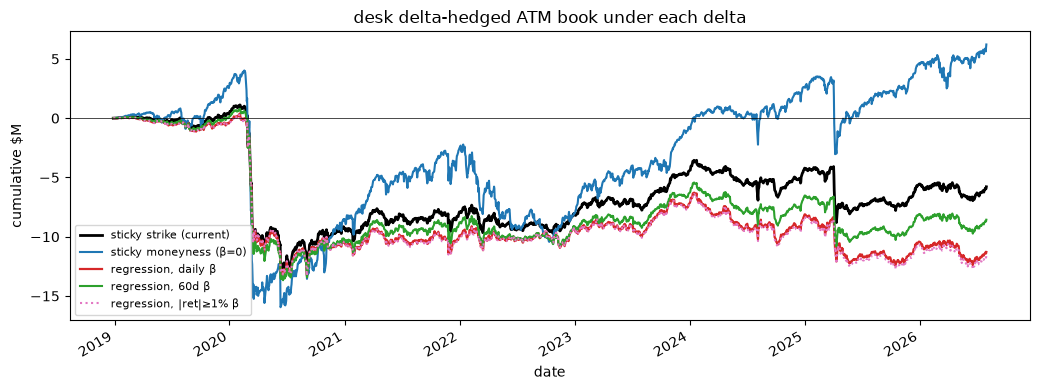

In [4]:
carry = ss["theta_value"] + ss["theta_delta"]
covid = (rd.index >= "2020-02-20") & (rd.index <= "2020-04-03")
H = {L: rd["pl"] - rd[f"eq_delta_{L}"] - carry for L in LABELS}
H["sm autograd"] = sm["pl"] - sm["eq_delta"] - carry
def stats(h):
    return pd.Series({"total $M": h.sum() / 1e6, "COVID $M": h[covid].sum() / 1e6,
                      "ex-COVID $M": h[~covid].sum() / 1e6, "std $k": h.std() / 1e3,
                      "ex-COVID std $k": h[~covid].std() / 1e3, "skew": h.skew(),
                      "worst day $M": h.min() / 1e6,
                      "corr ret_spx": np.corrcoef(h, rd["ret_spx"])[0, 1],
                      "corr ret_sx5e": np.corrcoef(h, rd["ret_sx5e"])[0, 1]})
summary = pd.DataFrame({(PRETTY.get(L, L)): stats(h) for L, h in H.items()}).T
print(summary.round(2).to_string())

fig, ax = plt.subplots(figsize=(10.5, 4))
for L, st in [("ss", dict(color="k", lw=2)), ("sm", dict(color="C0")), ("h1", dict(color="C3", lw=1.6)),
              ("h60", dict(color="C2")), ("big", dict(color="C6", ls=":"))]:
    (H[L].cumsum() / 1e6).plot(ax=ax, label=PRETTY[L], **st)
ax.axhline(0, color="k", lw=0.5)
ax.legend(fontsize=8)
ax.set(ylabel="cumulative $M", title="desk delta-hedged ATM book under each delta")
plt.tight_layout()

yr = pd.DataFrame({PRETTY[L]: H[L] for L in ["ss", "sm", "h1", "h60"]}).groupby(rd.index.year).sum() / 1e6
print("\nhedged P&L by year, $M\n" + yr.round(2).to_string())

The exact result lands where the cache-only proxy in the changelog
predicted it:

- **Lowest daily variance, better tail, less market beta.** The daily-β
  regression delta cuts the desk's std from \$182k to \$177k (−2.6%; ex-COVID
  \$151k → \$146k), lifts the skew from −4.0 to −3.5, trims COVID from
  −\$10.8M to −\$10.0M at the same worst day (−\$2.2M), and halves the
  residual SPX correlation (0.33 → 0.15). The in-sample β is the best case
  for all of these.
- **A worse drift.** Total −\$11.3M vs −\$5.8M for the current delta; ex
  COVID −\$1.3M vs +\$5.0M. Every rally year is worse (2021 +0.6 vs +1.4,
  2023 +1.9 vs +3.6, 2024 −0.9 vs +0.3, 2025 −2.3 vs −1.4) and only the bear
  year 2022 is better (+0.7 vs −0.1). The mechanism is the one the vol-trend
  decomposition found: the daily β is the mean-reverting level
  anticorrelation (vol falls on up days), so hedging it means holding less
  stock, the opposite direction from the slide that drives the trend.
- **Sticky moneyness is the mirror image.** +\$6.2M total and +\$24.9M ex
  COVID, but \$311k std, −\$18.7M in COVID, a −\$4.3M worst day and
  corr 0.68 with SPX — a long-equity tilt that paid in a bull market. The
  frozen-table bump reproduces the autograd delta's P&L to \$0.03M, so the
  three deltas really are one bump with three βs.

## The horizon ladder

The same book hedged with β estimated from 1-, 5-, 20- and 60-day changes,
with sticky strike and sticky moneyness as the two reference points. Two
objectives, one axis: daily variance (what the hedge is *for* day to day,
and what VaR sees) against the cumulative drift (what the desk books over
seven years).

                         std $k  ex-COVID std $k  total $M  ex-COVID $M  corr ret_spx
sticky strike (current)  181.52           150.91     -5.79         5.01          0.33
regression, daily β      176.84           145.99    -11.29        -1.29          0.15
regression, 5d β         179.12           146.28    -10.71        -0.46          0.19
regression, 20d β        179.21           146.68    -10.48        -0.10          0.19
regression, 60d β        187.68           150.41     -8.57         2.86          0.30
sticky moneyness (β=0)   310.64           254.77      6.22        24.94          0.68


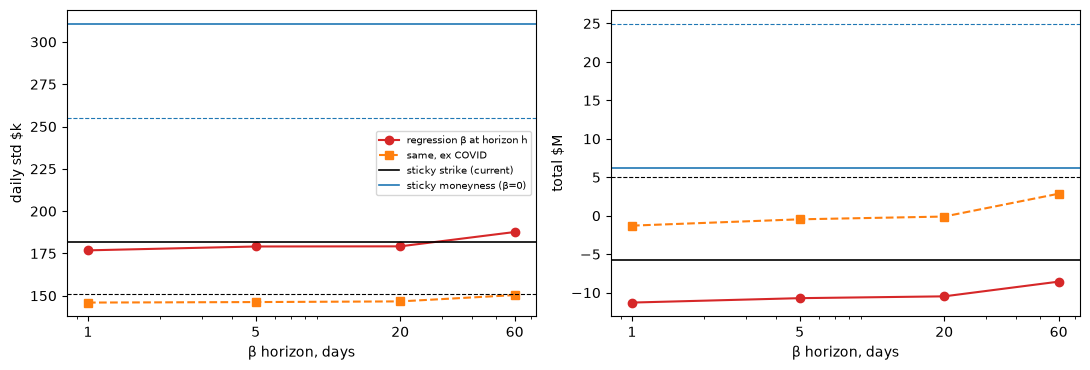

In [5]:
hz = [("h1", 1), ("h5", 5), ("h20", 20), ("h60", 60)]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, (metric, lab) in zip(axes, [(lambda h: h.std() / 1e3, "daily std $k"),
                                    (lambda h: h.sum() / 1e6, "total $M")]):
    xs = [d for _, d in hz]
    ax.plot(xs, [metric(H[L]) for L, _ in hz], "o-", color="C3", label="regression β at horizon h")
    ax.plot(xs, [metric(H[L][~covid]) for L, _ in hz], "s--", color="C1", label="same, ex COVID")
    for L, c in [("ss", "k"), ("sm", "C0")]:
        ax.axhline(metric(H[L]), color=c, lw=1.2, label=PRETTY[L])
        ax.axhline(metric(H[L][~covid]), color=c, lw=0.8, ls="--")
    ax.set(xscale="log", xlabel="β horizon, days", ylabel=lab, xticks=xs, xticklabels=[str(x) for x in xs])
axes[0].legend(fontsize=7)
plt.tight_layout()
lad = pd.DataFrame({PRETTY[L]: [H[L].std() / 1e3, H[L][~covid].std() / 1e3, H[L].sum() / 1e6, H[L][~covid].sum() / 1e6,
                                np.corrcoef(H[L], rd["ret_spx"])[0, 1]] for L in ["ss"] + [L for L, _ in hz] + ["sm"]},
                   index=["std $k", "ex-COVID std $k", "total $M", "ex-COVID $M", "corr ret_spx"]).T
print(lad.round(2).to_string())

The ladder is monotone and it does **not** pass through the current delta.
As the β horizon lengthens the regression delta moves toward sticky strike:
std rises (\$177k → \$179k → \$179k → \$188k) and the drift improves
(−\$11.3M → −\$10.7M → −\$10.5M → −\$8.6M), but at 60 days the std is
already worse than sticky strike's \$182k while the total is still \$2.8M
behind it. Sticky strike is on the frontier: no regression horizon beats it
on both objectives, and sticky moneyness is the other end of the frontier
(best drift, worst variance). The choice is the objective — daily variance
(VaR, hedge slippage) says the daily β; cumulative P&L says sticky strike
or beyond — and no β surface serves both, because the spot–vol link that
dominates daily variance (level) and the one that dominates the trend
(slide) have opposite signs.

## The vol line under the regression cut

With the regression delta the natural attribution moves the surface's
regression-implied response into `eq` and leaves `vol` as the regression
*residual* of the surface. `eq + vol + cross` is the same under every cut.

                         vol total $M  vol COVID $M  vol ex-COVID $M  vol std $k  corr(vol, ret_spx)  eq total $M  cross total $M  vol_spx $M  vol_sx5e $M  vol_hsi $M
sticky strike (current)        -22.02         -6.08           -15.94      146.38                0.40      -167.49            6.20      -14.66        -6.58       -0.95
sticky moneyness (β=0)         -16.32        -15.46            -0.85      291.92                0.73      -187.72           20.73       -9.68        -5.94       -0.94
regression, daily β            -30.99         -5.96           -25.03      142.56                0.18      -156.17            3.85      -19.93       -10.10       -0.94

vol line by year, $M
      sticky strike (current)  sticky moneyness (β=0)  regression, daily β
date                                                                      
2018                     0.00                    0.00                 0.00
2019                    -1.81                    0.25                -2.74
2020      

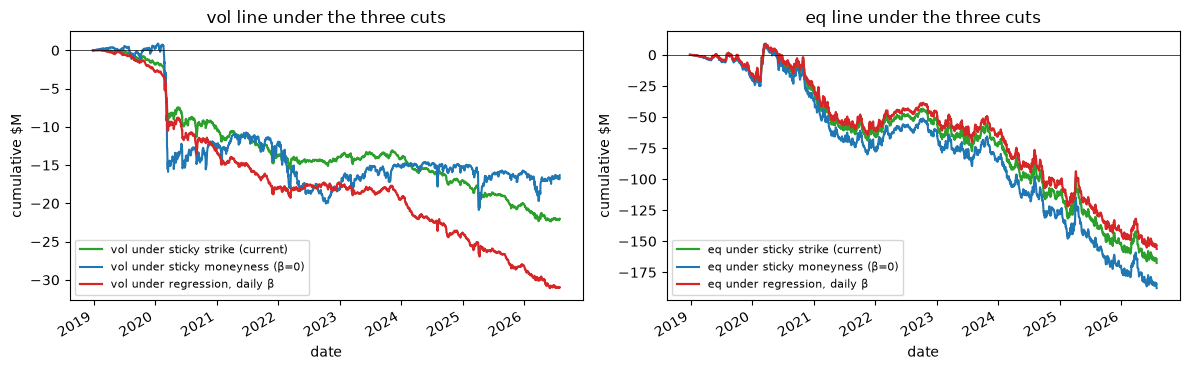

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for L, st in [("ss", dict(color="C2", lw=1.6)), ("sm", dict(color="C0")), ("h1", dict(color="C3", lw=1.6))]:
    (rd[f"vol_{L}"].cumsum() / 1e6).plot(ax=axes[0], label=f"vol under {PRETTY[L]}", **st)
    (rd[f"eq_{L}"].cumsum() / 1e6).plot(ax=axes[1], label=f"eq under {PRETTY[L]}", **st)
for ax, t in zip(axes, ["vol line", "eq line"]):
    ax.axhline(0, color="k", lw=0.5)
    ax.legend(fontsize=8)
    ax.set(ylabel="cumulative $M", title=f"{t} under the three cuts")
plt.tight_layout()
rows = {}
for L in ["ss", "sm", "h1"]:
    v = rd[f"vol_{L}"]
    rows[PRETTY[L]] = {"vol total $M": v.sum() / 1e6, "vol COVID $M": v[covid].sum() / 1e6, "vol ex-COVID $M": v[~covid].sum() / 1e6,
                       "vol std $k": v.std() / 1e3, "corr(vol, ret_spx)": np.corrcoef(v, rd["ret_spx"])[0, 1],
                       "eq total $M": rd[f"eq_{L}"].sum() / 1e6, "cross total $M": rd[f"cross_{L}"].sum() / 1e6,
                       **{f"vol_{n} $M": rd[f"vol_{L}_{n}"].sum() / 1e6 for n in IDX}}
print(pd.DataFrame(rows).T.round(2).to_string())
yrv = pd.DataFrame({PRETTY[L]: rd[f"vol_{L}"] for L in ["ss", "sm", "h1"]}).groupby(rd.index.year).sum() / 1e6
print("\nvol line by year, $M\n" + yrv.round(2).to_string())

The regression cut's vol line is the surface move *orthogonal to spot* —
and it trends **more**, not less: −\$31.0M total, −\$25.0M ex COVID, vs
−\$22.0M / −\$15.9M at fixed strike and −\$16.3M / −\$0.9M at fixed
moneyness. Every rally year is more negative than under sticky strike
(2021 −4.7 vs −3.5, 2024 −4.4 vs −2.9, 2025 −4.3 vs −3.2). The reason is
the sign of what was removed: the daily response the regression delta moves
into `eq` is "vol falls when spot rises", which in a seven-year rally was a
*gain* for the short-vega book; strip it out and the residual is the
one-way loss. Its correlation with the SPX return drops from 0.40 (fixed
strike) to 0.18, so the regression does make the vol line a cleaner
"pure vol" series day to day — it just confirms that the trend was never
a daily-correlation effect. The per-index split: SPX −\$19.9M, SX5E −\$10.1M,
HSI −\$0.9M.

## Big moves

A linear β is a daily-average response. The level piece of the surface is
convex in the move (vol jumps after big moves in either direction), so a
delta tuned to average days under-hedges the crash days. The `big` β
(|ret| ≥ 1% days) tests whether re-tuning helps, and the binned view shows
where each delta's hedged P&L comes from.

hedged P&L summed by SPX-return bucket, $M
                 sticky strike (current)  sticky moneyness (β=0)  regression, daily β  regression, |ret|≥1% β  days
ret_spx                                                                                                            
(-1.0, -0.03]                     -16.95                  -34.06               -14.45                  -13.85    27
(-0.03, -0.02]                     -7.70                  -22.24                -3.76                   -3.32    45
(-0.02, -0.01]                     -8.12                  -40.21                 1.41                    2.24   165
(-0.01, -0.005]                    -4.63                  -27.01                 2.08                    2.66   208
(-0.005, 0.005]                    20.19                   20.94                20.28                   20.28   930
(0.005, 0.01]                       9.57                   41.30                -0.14                   -0.91   303
(0.01, 0.02]                 


big-move β vs daily β: hedged total -11.64M vs -11.29M, std 176k vs 177k, COVID -9.76M vs -10.00M
notebook runtime 2.3s


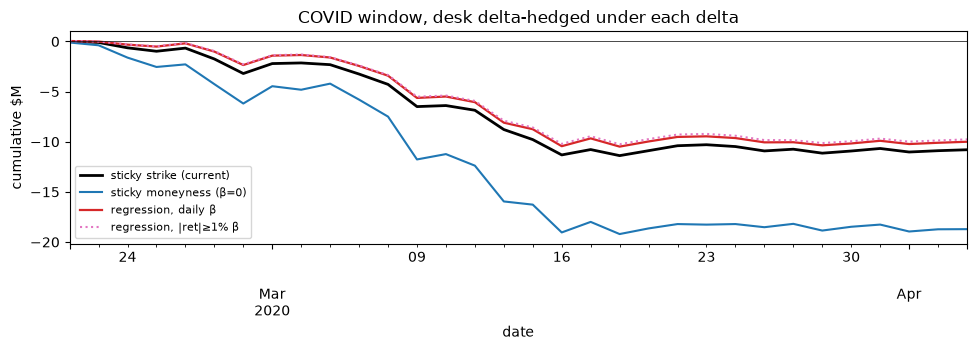

In [7]:
bins = [-1, -0.03, -0.02, -0.01, -0.005, 0.005, 0.01, 0.02, 0.03, 1]
cat = pd.cut(rd["ret_spx"], bins)
binned = pd.DataFrame({PRETTY[L]: H[L].groupby(cat, observed=True).sum() / 1e6 for L in ["ss", "sm", "h1", "big"]})
binned["days"] = cat.value_counts().sort_index()
print("hedged P&L summed by SPX-return bucket, $M\n" + binned.round(2).to_string())
w = rd.index[covid]
fig, ax = plt.subplots(figsize=(10, 3.6))
for L, st in [("ss", dict(color="k", lw=2)), ("sm", dict(color="C0")), ("h1", dict(color="C3", lw=1.6)), ("big", dict(color="C6", ls=":"))]:
    (H[L].loc[w].cumsum() / 1e6).plot(ax=ax, label=PRETTY[L], **st)
ax.axhline(0, color="k", lw=0.5)
ax.legend(fontsize=8)
ax.set(ylabel="cumulative $M", title="COVID window, desk delta-hedged under each delta")
plt.tight_layout()
print(f"\nbig-move β vs daily β: hedged total {H['big'].sum() / 1e6:+.2f}M vs {H['h1'].sum() / 1e6:+.2f}M, "
      f"std {H['big'].std() / 1e3:.0f}k vs {H['h1'].std() / 1e3:.0f}k, COVID {H['big'][covid].sum() / 1e6:+.2f}M vs {H['h1'][covid].sum() / 1e6:+.2f}M")
print(f"notebook runtime {time.time() - T0:.1f}s")

The binned view shows what the regression delta trades. On down days it
is the better hedge everywhere: the 165 days in (−2%, −1%] cost sticky
strike −\$8.1M and *make* the regression delta +\$1.4M; the 27 crash days
below −3% cost −\$14.5M vs −\$17.0M. The bill arrives on up days: the 232
days in (+1%, +2%] make sticky strike +\$1.9M and cost the regression delta
−\$12.2M. In a rally there are more and bigger up-day buckets than down-day
ones, so the redistribution nets to the −\$5.5M drift difference. The
big-move β (|ret| ≥ 1% days only) is almost indistinguishable from the
daily β — total −\$11.6M vs −\$11.3M, std \$176k vs \$177k, COVID −\$9.8M
vs −\$10.0M — because the full-sample OLS already weights the big days;
the convexity that the crash days carry (vol jumps on moves of *either*
sign) is not a slope and no linear β reaches it. Sticky moneyness loses
−\$34M on the 27 crash days alone and makes +\$49M on the (+1%, +2%] bucket:
that is a market position, not a hedge.

## Takeaways

- **One bump, three βs.** Sticky moneyness (β = 0), sticky strike (β = the
  smile slope m·∂σ/∂m) and the regression delta (β = the data's per-pillar
  slope) are the same central bump through the factory's `dgrid` seam; the
  `ss` label reproduces the attribution cache to fp and β = 0 reproduces the
  autograd delta's P&L to \$0.03M. Empirically the data's β is ~90% of the
  sticky-strike β at the money, nearly flat in moneyness, and almost
  horizon-independent (SPX 1Y ATM −0.42 daily, −0.37 at 60 days = the
  sticky-strike value).
- **The regression delta is the minimum-variance delta and behaves like
  one**: std −2.6% (−3.3% ex COVID), skew −4.0 → −3.5, COVID −\$0.8M better,
  SPX correlation halved — and the drift worsens by \$5.5M (−\$11.3M vs
  −\$5.8M; ex COVID −\$1.3M vs +\$5.0M) because it holds *less* stock than
  the current delta while the trend wants more. In-sample βs are the best
  case for the variance numbers.
- **No horizon dominates sticky strike.** Lengthening the β horizon walks
  the delta toward sticky strike, but std passes it (60d: \$188k vs \$182k)
  before the drift catches up (−\$8.6M vs −\$5.8M). The frontier is daily-β
  (variance) — sticky strike — sticky moneyness (drift); pick by objective.
- **The vol line does not become range-bound** under the regression cut — it
  trends harder (−\$31M, −\$25M ex COVID) because the response removed was a
  rally gain. The slide that drives the trend is a coordinate effect
  (fixed strike vs stationary moneyness), not a daily correlation, and only
  the sticky-moneyness cut moves it out of the vol line.
- **For cheap VaR**: the regression delta's hedged book has the lowest daily
  std and the shortest left tail of the three, which is the quantity a VaR
  engine on the hedged book sees; the co-moved surface bump is the same
  seam the spot×factor cross corners already use, so it costs nothing
  extra to carry as a second delta in `rainbow_bump_greeks`.